# Rafael TCC - Projeto 04

## Análise Multivariada

Empregando como variáveis explicativas a posição relativa das DEPs (TOPs)

### Bibliotecas

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


### Leitura do arquivo de dados

In [2]:
programa = 'ANCP'
df_valid = pd.read_csv(f'Dados/CSV/NeloreCRV_{programa}_valido.csv')

### Random Forest Feature

Avaliando a contribuição relativa de todas as 18 características no preço

RANKING MULTIVARIADO: IMPORTÂNCIA RELATIVA DE CADA CARACTERÍSTICA NA FORMAÇÃO DO PREÇO


,Característica,Importância Relativa (%),Importância Acumulada (%)
0,CAR (Consumo Residual),14.44,14.44
1,3P (Precocidade),9.58,24.02
2,MP210 (Maternal 210d),6.15,30.17
3,MP120 (Maternal 120d),5.62,35.79
4,PN (Peso Nascer),5.39,41.18
5,FPP (Facilidade Parto),5.38,46.56
6,ACAB (Acabamento),5.12,51.67
7,STAY (Longevidade),5.09,56.77
8,AOL (Musculatura),4.88,61.64
9,P450 (Sobreano),4.67,66.31


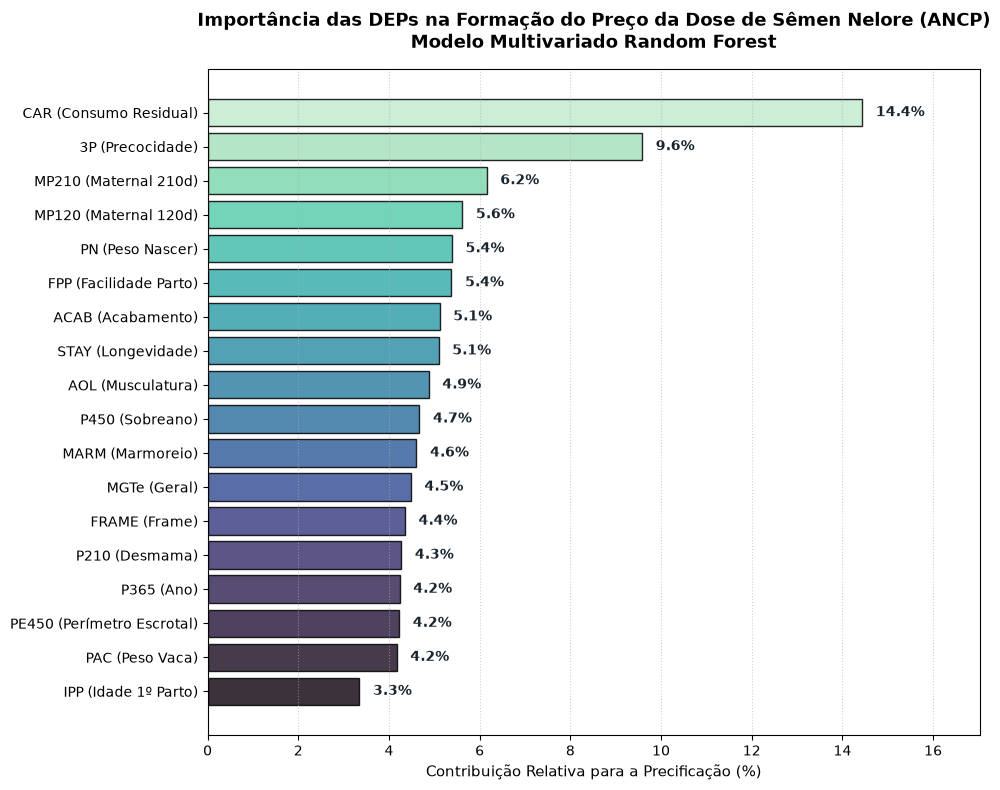

In [3]:
# 1. Mapeamento das 18 variáveis explicativas (X) e da variável resposta (y)
features_dict = {
    'MGTe_TOP': 'MGTe (Geral)',
    'P210_TOP': 'P210 (Desmama)',
    'P365_TOP': 'P365 (Ano)',
    'P450_TOP': 'P450 (Sobreano)',
    'FRAME_TOP': 'FRAME (Frame)',
    'PAC_TOP': 'PAC (Peso Vaca)',
    '3P_TOP': '3P (Precocidade)',
    'IPP_TOP': 'IPP (Idade 1º Parto)',
    'STAY_TOP': 'STAY (Longevidade)',
    'PE450_TOP': 'PE450 (Perímetro Escrotal)',
    'MP120_TOP': 'MP120 (Maternal 120d)',
    'MP210_TOP': 'MP210 (Maternal 210d)',
    'PN_TOP': 'PN (Peso Nascer)',
    'FPP_TOP': 'FPP (Facilidade Parto)',
    'AOL_TOP': 'AOL (Musculatura)',
    'ACAB_TOP': 'ACAB (Acabamento)',
    'MARM_TOP': 'MARM (Marmoreio)',
    'CAR_TOP': 'CAR (Consumo Residual)'
}

# Filtrar colunas existentes e tratar eventuais dados faltantes pontuais
cols_x = [c for c in features_dict.keys() if c in df_valid.columns]
X = df_valid[cols_x].copy()
y = df_valid['SEMEM'].copy()

# Preencher eventuais NaNs pontuais com a mediana da coluna (para o modelo rodar redondo)
X = X.fillna(X.median())

# 2. Ajuste do Modelo Random Forest (500 árvores para estabilidade)
rf = RandomForestRegressor(n_estimators=500, random_state=42, max_features='sqrt')
rf.fit(X, y)

# 3. Extração e Normalização das Importâncias (em %)
importancias = pd.Series(rf.feature_importances_ * 100, index=[features_dict[c] for c in cols_x])
importancias = importancias.sort_values(ascending=True)

# 4. Tabela de Importância Relativa
df_imp = pd.DataFrame({
    'Característica': importancias.index[::-1],
    'Importância Relativa (%)': importancias.values[::-1].round(2),
    'Importância Acumulada (%)': importancias.values[::-1].cumsum().round(2)
})

print("=" * 80)
print("RANKING MULTIVARIADO: IMPORTÂNCIA RELATIVA DE CADA CARACTERÍSTICA NA FORMAÇÃO DO PREÇO")
print("=" * 80)
display(df_imp)

# 5. Gráfico de Barras Horizontal (Padrão Publicação / TCC)
plt.figure(figsize=(10, 8))
cores = sns.color_palette("mako", len(importancias))

barras = plt.barh(importancias.index, importancias.values, color=cores, edgecolor='black', alpha=0.85)

for b in barras:
    w = b.get_width()
    plt.text(w + 0.3, b.get_y() + b.get_height()/2, f"{w:.1f}%", 
             va='center', ha='left', fontsize=10, fontweight='bold', color='#1a252f')

plt.title("Importância das DEPs na Formação do Preço da Dose de Sêmen Nelore (ANCP)\nModelo Multivariado Random Forest", 
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Contribuição Relativa para a Precificação (%)", fontsize=11)
plt.xlim(0, importancias.max() * 1.18)
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


### Regressão Hedônica Clássica (OLS)

Isolando o impacto ceteris paribus das DEPs líderes sobre o preço

In [4]:
# 1. Seleção das variáveis líderes apontadas pelo Random Forest
variaveis_modelo = [
    'CAR_TOP',   # Eficiência Alimentar (1º lugar no RF)
    '3P_TOP',    # Precocidade Sexual Feminina (2º lugar no RF)
    'MP210_TOP',  # Habilidade Maternal Desmama (3º lugar no RF)
    'FPP_TOP',   # Facilidade de Parto em Primíparas (4º lugar no RF)
    'AOL_TOP',   # Musculatura / Carcaça (6º lugar no RF)
    'P450_TOP'   # Peso ao Sobreano (Crescimento)
]

# Preparar base de regressão sem dados faltantes nas variáveis do modelo
df_reg = df_valid.dropna(subset=['SEMEM'] + variaveis_modelo).copy()
print(f"Número de observações válidas utilizadas na Regressão: N = {len(df_reg)}")

# 2. Definição de X (adicionando a constante/intercepto) e y
X_ols = df_reg[variaveis_modelo].copy()
X_ols_com_constante = sm.add_constant(X_ols)
y_ols = df_reg['SEMEM'].copy()

# 3. Ajuste do Modelo de Mínimos Quadrados Ordinários (OLS)
modelo_ols = sm.OLS(y_ols, X_ols_com_constante).fit()

# 4. Tabela de Coeficientes Formatada com Nível de Significância
tabela_coef = pd.DataFrame({
    'Coeficiente (Beta R$)': modelo_ols.params.round(3),
    'Erro Padrão': modelo_ols.bse.round(3),
    'Estatística t': modelo_ols.tvalues.round(2),
    'p-valor': modelo_ols.pvalues.round(4)
})

# Adicionar estrelas de significância acadêmica
def formatar_significancia(p):
    if p < 0.01: return '*** (Signif. a 1%)'
    if p < 0.05: return '** (Signif. a 5%)'
    if p < 0.10: return '* (Signif. a 10%)'
    return 'Não significativo'

tabela_coef['Significância'] = tabela_coef['p-valor'].apply(formatar_significancia)

# Renomear os índices para exibição bonita
nomes_legiveis = {
    'const': 'Intercepto (Preço Base)',
    'DCAR_TOP': 'DCAR_TOP (Consumo Residual)',
    'D3P_TOP': 'D3P_TOP (Precocidade Parto)',
    'MP210_TOP': 'MP210_TOP (Maternal 210 dias)',
    'DFPP_TOP': 'DFPP_TOP (Facilidade Parto)',
    'DAOL_TOP': 'DAOL_TOP (Musculatura Carcaça)',
    'DP450_TOP': 'DP450_TOP (Peso Sobreano)'
}
tabela_coef.index = [nomes_legiveis.get(i, i) for i in tabela_coef.index]

print("=" * 85)
print(f"RESULTADOS DA REGRESSÃO HEDÔNICA MULTIVARIADA (R² = {modelo_ols.rsquared:.3f} | R² Ajustado = {modelo_ols.rsquared_adj:.3f})")
print(f"Estatística F = {modelo_ols.fvalue:.2f} (p-valor do Modelo = {modelo_ols.f_pvalue:.4e})")
print("=" * 85)
display(tabela_coef)

Número de observações válidas utilizadas na Regressão: N = 115
RESULTADOS DA REGRESSÃO HEDÔNICA MULTIVARIADA (R² = 0.087 | R² Ajustado = 0.036)
Estatística F = 1.72 (p-valor do Modelo = 1.2401e-01)


,Coeficiente (Beta R$),Erro Padrão,Estatística t,p-valor,Significância
Intercepto (Preço Base),36.297,2.012,18.04,0.0000,*** (Signif. a 1%)
CAR_TOP,-0.055,0.021,-2.57,0.0116,** (Signif. a 5%)
3P_TOP,0.014,0.033,0.42,0.6757,Não significativo
MP210_TOP (Maternal 210 dias),-0.025,0.027,-0.94,0.3514,Não significativo
FPP_TOP,-0.023,0.022,-1.03,0.3049,Não significativo
AOL_TOP,-0.021,0.052,-0.41,0.6855,Não significativo
P450_TOP,-0.011,0.081,-0.14,0.8909,Não significativo


#### Diagnóstico de multicolinearidade (VIF - variance inflation factor)

In [5]:
vif_data = pd.DataFrame()
vif_data['Característica'] = [nomes_legiveis.get(c, c) for c in variaveis_modelo]
vif_data['VIF'] = [variance_inflation_factor(X_ols.values, i) for i in range(X_ols.shape[1])]
vif_data['VIF'] = vif_data['VIF'].round(2)
vif_data['Diagnóstico'] = vif_data['VIF'].apply(lambda x: 'Excelente (< 5)' if x < 5 else ('Aceitável (< 10)' if x < 10 else 'Alerta (> 10)'))

print("\n" + "=" * 85)
print("DIAGNÓSTICO DE MULTICOLINEARIDADE (VIF)")
print("=" * 85)
display(vif_data)


DIAGNÓSTICO DE MULTICOLINEARIDADE (VIF)


,Característica,VIF,Diagnóstico
0,CAR_TOP,1.08,Excelente (< 5)
1,3P_TOP,1.29,Excelente (< 5)
2,MP210_TOP (Maternal 210 dias),1.26,Excelente (< 5)
3,FPP_TOP,1.48,Excelente (< 5)
4,AOL_TOP,2.06,Excelente (< 5)
5,P450_TOP,2.84,Excelente (< 5)


#### Modelo hedônico com dummies das classes (capturando o efeito degrau)

In [9]:
# Criar variáveis Dummy para a Super Elite das características líderes
df_reg['SUPER_CAR'] = (df_reg['CAR_TOP'] <= 3.0).astype(int)
df_reg['SUPER_3P']  = (df_reg['3P_TOP'] <= 3.0).astype(int)
df_reg['SUPER_AOL'] = (df_reg['AOL_TOP'] <= 3.0).astype(int)
df_reg['SUPER_P450']= (df_reg['P450_TOP'] <= 3.0).astype(int)
df_reg['SUPER_MGTe'] = (df_reg['MGTe_TOP'] <= 3.0).astype(int)

X_dummy = df_reg[['SUPER_CAR', 'SUPER_3P', 'SUPER_AOL', 'SUPER_P450', 'SUPER_MGTe']]
X_dummy_const = sm.add_constant(X_dummy)

modelo_dummy = sm.OLS(df_reg['SEMEM'], X_dummy_const).fit()

tabela_dummy = pd.DataFrame({
    'Ágio Médio (Beta R$)': modelo_dummy.params.round(2),
    'p-valor': modelo_dummy.pvalues.round(4)
})
tabela_dummy['Significância'] = tabela_dummy['p-valor'].apply(formatar_significancia)

print("=" * 80)
print(f"REGRESSÃO HEDÔNICA POR DUMMIES DE SUPER ELITE (R² = {modelo_dummy.rsquared:.3f})")
print("=" * 80)
display(tabela_dummy)


REGRESSÃO HEDÔNICA POR DUMMIES DE SUPER ELITE (R² = 0.144)


,Ágio Médio (Beta R$),p-valor,Significância
const,31.01,0.0000,*** (Signif. a 1%)
SUPER_CAR,6.71,0.0002,*** (Signif. a 1%)
SUPER_3P,-1.50,0.3820,Não significativo
SUPER_AOL,2.16,0.1948,Não significativo
SUPER_P450,-0.92,0.6339,Não significativo
SUPER_MGTe,1.79,0.3960,Não significativo
